In [4]:
from google.colab import files
files.upload()
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["font.size"] = plt.rcParamsDefault["font.size"]

Saving data_banknote_authentication.txt to data_banknote_authentication (1).txt


In [3]:
import pandas as pd
from matplotlib.figure import figaspect
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Import the files
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=["variance", "skewness", "curtosis", "entropy", "target"])
print(df.head())

   variance  skewness  curtosis  entropy  target
0   3.62160    8.6661   -2.8073 -0.44699       0
1   4.54590    8.1674   -2.4586 -1.46210       0
2   3.86600   -2.6383    1.9242  0.10645       0
3   3.45660    9.5228   -4.0112 -3.59440       0
4   0.32924   -4.4552    4.5718 -0.98880       0


In [6]:
#About the Dataset
print("Shape and dimensions of the dataset: ", df.shape, "and", df.ndim)
print("\nNo.of null values: ")
print(df.isna().sum(),"\n")
print("Descriptive statistics:")
print(df.describe())

Shape and dimensions of the dataset:  (1372, 5) and 2

No.of null values: 
variance    0
skewness    0
curtosis    0
entropy     0
target      0
dtype: int64 

Descriptive statistics:
          variance     skewness     curtosis      entropy       target
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


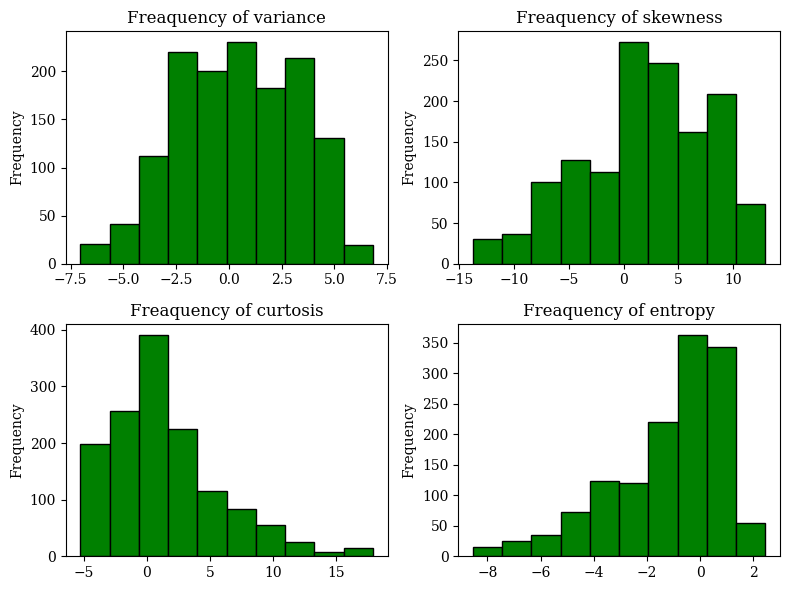

In [7]:
#Histogram
features = ["variance", "skewness", "curtosis", "entropy"]

plt.figure(figsize=(8, 6))
for i, feature in enumerate(features):
  plt.subplot(2,2,i+1)
  plt.hist(df[feature], edgecolor="k", color="green")
  plt.title(f"Freaquency of {feature}")
  plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

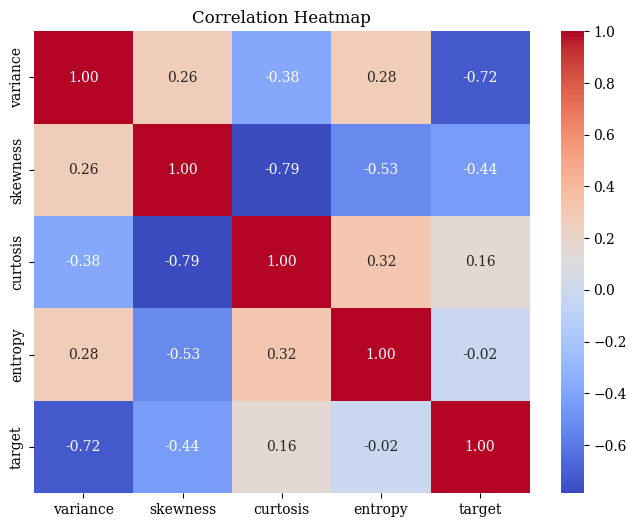

In [8]:
#Correlation heatmap
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

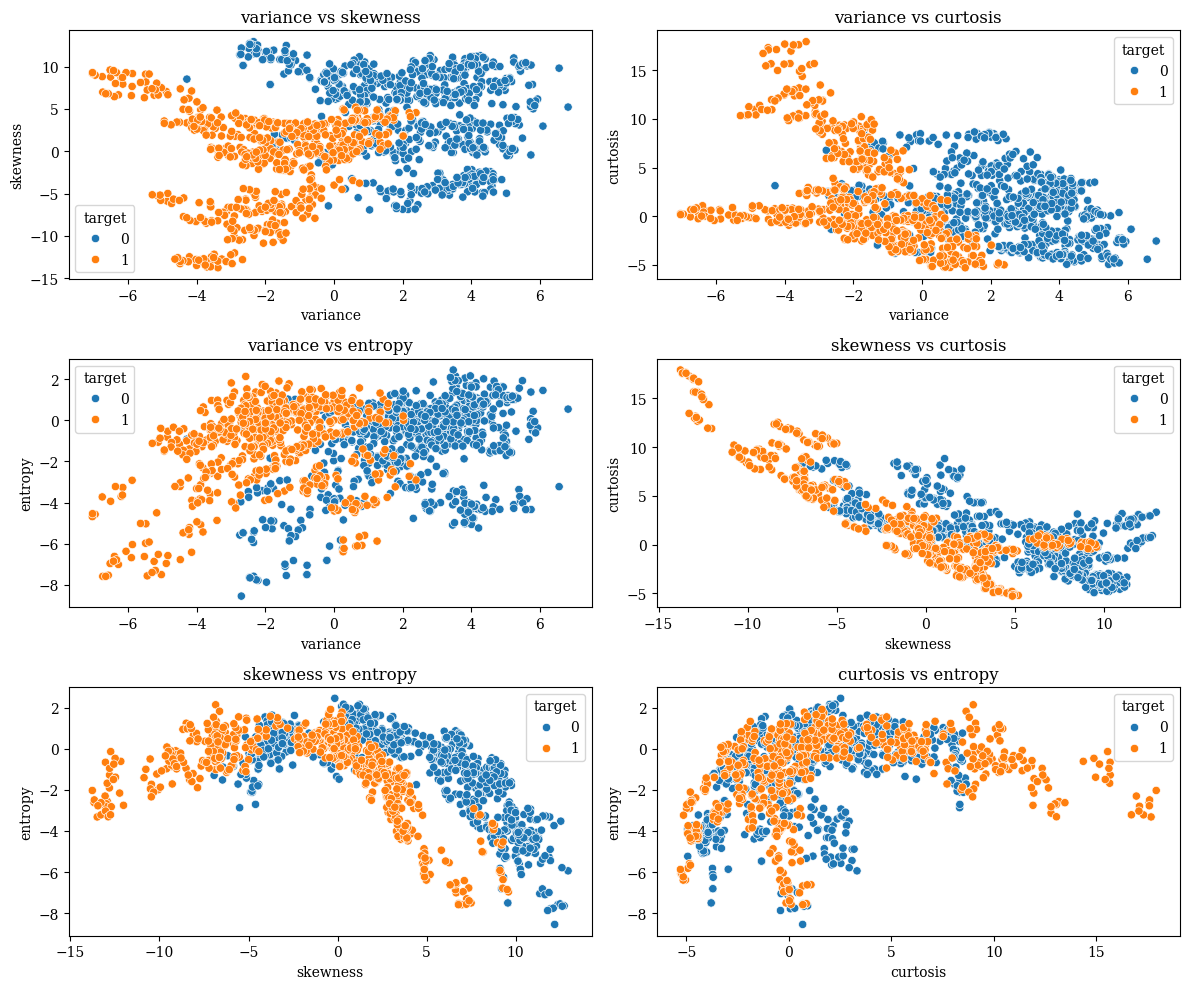

In [9]:
#Scatter Plot
features = ["variance", "skewness", "curtosis", "entropy"]
plt.figure(figsize=(12, 10))
plot_number = 1
for i in range(len(features)):
  for j in range(i+1, len(features)):
        plt.subplot(3,2, plot_number)
        sns.scatterplot(data=df, x=features[i], y=features[j], hue="target")
        plt.title(f"{features[i]} vs {features[j]}")
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        plot_number += 1
plt.tight_layout()
plt.show()

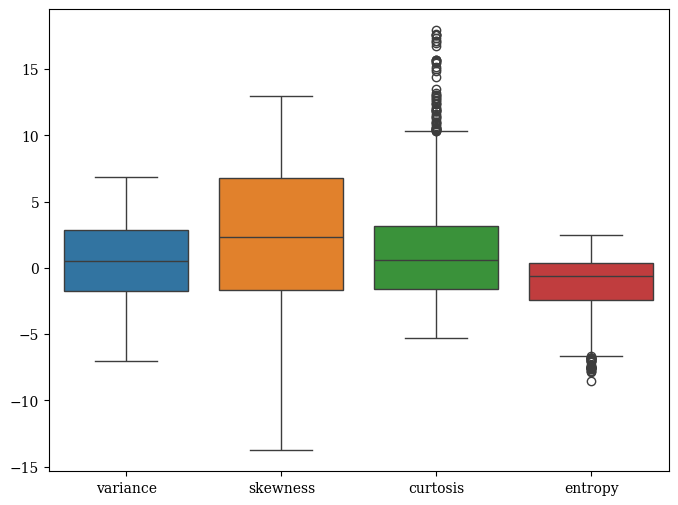

In [10]:
#Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[features])
plt.show()

In [11]:
#Spilitting Data and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop("target", axis=1)
y = df["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
import numpy as np

#Perceptron Implementation
class Perceptron:
  def __init__(self, n=0.01, epochs=100):
    self.n = n
    self.epochs = epochs
    self.weights = None
    self.bias = 0
    self.errors = []
    self.weight_history = []
    self.bias_history = []

  def fit(self, x, y):
    self.weights = np.zeros(x.shape[1])
    self.bias = 0.0
    self.errors = []
    self.weight_history = []
    self.bias_history = []

    for epoch in range(self.epochs):
      errors_in_epochs = 0
      for i in range(len(x)):
        z = np.dot(x[i], self.weights) + self.bias
        y_pred = 1 if z>0 else 0
        error = y[i] - y_pred

        if error!=0:
          self.weights = self.weights + (self.n * error * x[i])
          self.bias = self.bias + (self.n * error)
          errors_in_epochs += 1
      self.errors.append(errors_in_epochs)
      self.weight_history.append(self.weights.copy())
      self.bias_history.append(self.bias)

      current_epoch = epoch + 1
      if current_epoch == 1 or current_epoch % 10 == 0 or current_epoch == self.epochs:
        w1 = round(self.weights[0], 4)
        w2 = round(self.weights[1], 4)
        w3 = round(self.weights[2], 4)
        w4 = round(self.weights[3], 4)
        b = round(self.bias, 4)
        print(f"{current_epoch} --- {errors_in_epochs} & {w1} & {w2} & {w3} & {w4} & {b} \\\\")

  def predict(self, x):
    z = np.dot(x, self.weights) + self.bias
    return np.where(z > 0, 1, 0)

1 --- 55 & -0.0744 & -0.0795 & -0.0405 & -0.0072 & -0.03 \\
10 --- 22 & -0.1174 & -0.1642 & -0.1079 & -0.0045 & -0.06 \\
20 --- 18 & -0.1364 & -0.1758 & -0.1582 & -0.0104 & -0.08 \\
30 --- 18 & -0.1444 & -0.196 & -0.174 & -0.0036 & -0.09 \\
40 --- 20 & -0.1851 & -0.2063 & -0.1629 & -0.0165 & -0.09 \\
50 --- 20 & -0.1817 & -0.2203 & -0.2043 & -0.0045 & -0.1 \\
60 --- 15 & -0.2078 & -0.2199 & -0.2138 & -0.0126 & -0.11 \\
70 --- 14 & -0.2045 & -0.2428 & -0.2273 & 0.0004 & -0.11 \\
80 --- 15 & -0.2323 & -0.2501 & -0.2273 & -0.0246 & -0.11 \\
90 --- 14 & -0.2391 & -0.2568 & -0.2354 & -0.0108 & -0.12 \\
100 --- 12 & -0.238 & -0.2625 & -0.2487 & -0.0192 & -0.13 \\
[-0.23796763 -0.26246497 -0.24866506 -0.01923165]
-0.12999999999999998


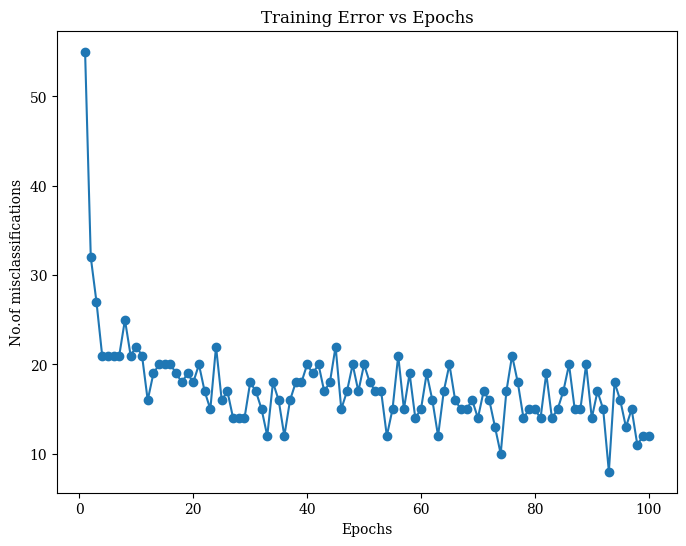


Accuracy:  0.9818181818181818
Precision:  1.0
Recall:  0.9606299212598425
F1 Score:  0.9799196787148594 



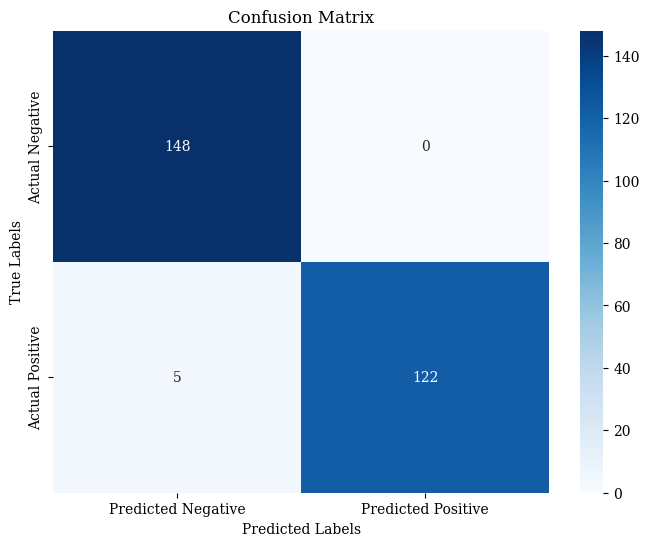

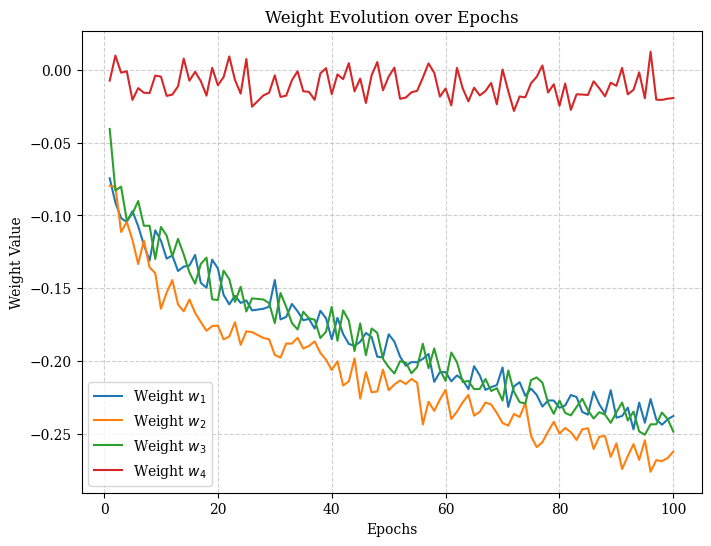

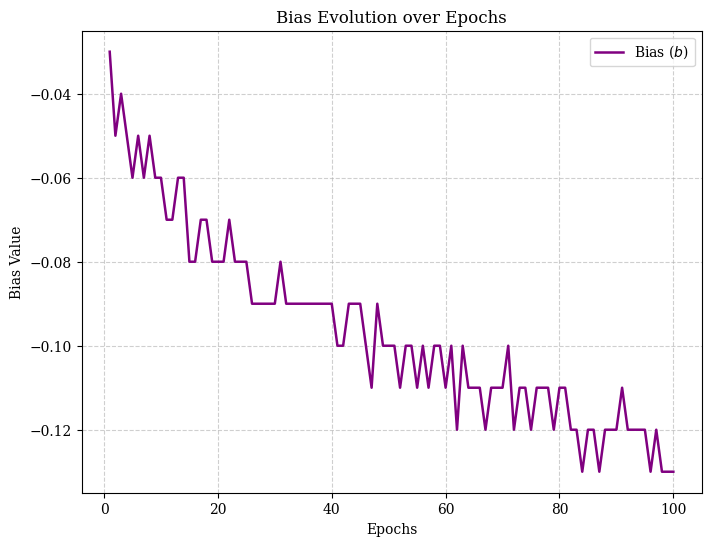

In [13]:
model = Perceptron()

model.fit(x_train_scaled, y_train.values)
y_pred = model.predict(x_test_scaled)
weight_history = np.array(model.weight_history)
bias_history = np.array(model.bias_history)
errors = model.errors
print(model.weights)
print(model.bias)

# Errors vs Epochs
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(errors) + 1), errors, marker='o', linewidth=1.5)
plt.xlabel("Epochs")
plt.ylabel('No.of misclassifications')
plt.title('Training Error vs Epochs')
plt.show()

#Confusion Matrix
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

total = tp + tn + fp + fn
accuracy = (tp + tn) / total if total > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("\nAccuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1,"\n")

confusion_matrix = np.array([[tn,fp],[fn,tp]])
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#Weights vs Epochs
print()
plt.figure(figsize=(8, 6))
for idx in range(weight_history.shape[1]):
    plt.plot(range(1, model.epochs + 1), weight_history[:, idx], label=f'Weight $w_{{{idx+1}}}$', linewidth=1.5)
plt.xlabel('Epochs')
plt.ylabel('Weight Value')
plt.title('Weight Evolution over Epochs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#Bais vs Epochs
print()
plt.figure(figsize=(8, 6))
plt.plot(range(1, model.epochs + 1), model.bias_history, color='purple', linewidth=1.8, label='Bias ($b$)')
plt.xlabel('Epochs')
plt.ylabel('Bias Value')
plt.title('Bias Evolution over Epochs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

1 --- 55 & -0.0074 & -0.008 & -0.0041 & -0.0007 & -0.003 \\
10 --- 22 & -0.0117 & -0.0164 & -0.0108 & -0.0004 & -0.006 \\
20 --- 18 & -0.0136 & -0.0176 & -0.0158 & -0.001 & -0.008 \\
30 --- 18 & -0.0144 & -0.0196 & -0.0174 & -0.0004 & -0.009 \\
40 --- 20 & -0.0185 & -0.0206 & -0.0163 & -0.0017 & -0.009 \\
50 --- 20 & -0.0182 & -0.022 & -0.0204 & -0.0004 & -0.01 \\
[55, 32, 27, 21, 21, 21, 21, 25, 21, 22, 21, 16, 19, 20, 20, 20, 19, 18, 19, 18, 20, 17, 15, 22, 16, 17, 14, 14, 14, 18, 17, 15, 12, 18, 16, 12, 16, 18, 18, 20, 19, 20, 17, 18, 22, 15, 17, 20, 17, 20]
1 --- 55 & -0.0744 & -0.0795 & -0.0405 & -0.0072 & -0.03 \\
10 --- 22 & -0.1174 & -0.1642 & -0.1079 & -0.0045 & -0.06 \\
20 --- 18 & -0.1364 & -0.1758 & -0.1582 & -0.0104 & -0.08 \\
30 --- 18 & -0.1444 & -0.196 & -0.174 & -0.0036 & -0.09 \\
40 --- 20 & -0.1851 & -0.2063 & -0.1629 & -0.0165 & -0.09 \\
50 --- 20 & -0.1817 & -0.2203 & -0.2043 & -0.0045 & -0.1 \\
[55, 32, 27, 21, 21, 21, 21, 25, 21, 22, 21, 16, 19, 20, 20, 20, 19, 1

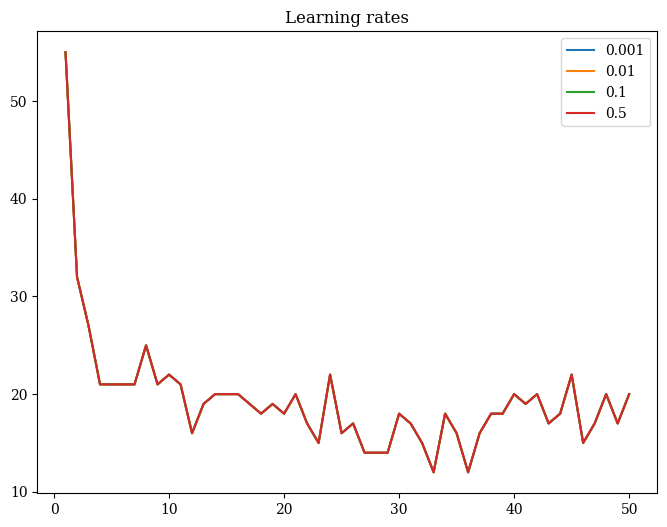

In [14]:
#Effect of learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5]

plt.figure(figsize=(8, 6))
for lr in learning_rates:
    model = Perceptron(n=lr, epochs=50)
    model.fit(x_train_scaled, y_train.values)
    plt.plot(range(1, len(model.errors) + 1), model.errors, label=f'{lr}', linewidth=1.5)
    print(model.errors)
plt.legend()
plt.title("Learning rates")
plt.show()

In [15]:
# Additional Tasks : AND, OR and NOT gate using Perceptron

import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
  def __init__(self, n=0.01, epochs=100, gate = ""):
    self.n = n
    self.epochs = epochs
    self.weights = None
    self.bias = 0
    self.errors = []
    self.weight_history = []
    self.bias_history = []
    self.gate  = gate

  def fit(self, x, y):
    self.weights = np.zeros(x.shape[1])
    self.bias = 0.0
    self.errors = []
    self.weight_history = []
    self.bias_history = []

    for epoch in range(self.epochs):
      errors_in_epochs = 0
      for i in range(len(x)):
        z = np.dot(x[i], self.weights) + self.bias
        y_pred = 1 if z>0 else 0
        error = y[i] - y_pred

        if error != 0:
            self.weights = self.weights + (self.n * error * x[i])
            self.bias = self.bias + (self.n * error)
            errors_in_epochs += 1
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
      print(f"--- End of Epoch {epoch+1}: Total Misclassifications = {errors_in_epochs} ---\n")
      self.errors.append(errors_in_epochs)
      if errors_in_epochs == 0:
        print(f"{self.gate} gate Perceptron converged after epoch {epoch+1}\n")
        break

  def predict(self, x):
    z = np.dot(x, self.weights) + self.bias
    return np.where(z > 0, 1, 0)

  def plot_boundary_history(self, x, y):
        n_updates = len(self.weight_history)
        if n_updates == 0:
            print(f"No updates were made for {self.gate} — already converged.\n")
            return

        cols = min(n_updates, 4)
        rows = (n_updates + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows), squeeze=False)
        axes = axes.flatten()

        x_min, x_max = -0.5, 1.5
        xx = np.linspace(x_min, x_max, 100)

        for i in range(n_updates):
            w = self.weight_history[i]
            b = self.bias_history[i]
            ax = axes[i]

            # 1D vs 2D plot handling
            if x.shape[1] == 1:
                ax.scatter(x[:, 0], np.zeros_like(x[:, 0]), c=y, cmap="bwr", edgecolor="k", s=100, zorder=3)
                if w[0] != 0:
                    boundary_x = -b / w[0]
                    ax.axvline(boundary_x, color="g", linestyle="--", label="Boundary")
                ax.set_ylim(-0.5, 0.5)
                ax.set_yticks([])
                ax.set_xlabel("X1")
            else:
                ax.scatter(x[:, 0], x[:, 1], c=y, cmap="bwr", edgecolor="k", s=100, zorder=3)
                if w[1] != 0:
                    yy = -(w[0] * xx + b) / w[1]
                    ax.plot(xx, yy, "g-")
                elif w[0] != 0:
                    ax.axvline(-b / w[0], color="g")
                ax.set_ylim(x_min, x_max)
                ax.set_xlabel("X1")
                ax.set_ylabel("X2")

            ax.set_xlim(x_min, x_max)
            ax.set_title(f"Update {i+1}", fontsize=10)
            ax.grid(True, linestyle=":", alpha=0.6)

        # Hide unused grid subplots
        for j in range(n_updates, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"{self.gate} Gate — Decision Boundary Evolution", fontsize=14, y=1.02)
        plt.show()

--- End of Epoch 1: Total Misclassifications = 1 ---

--- End of Epoch 2: Total Misclassifications = 3 ---

--- End of Epoch 3: Total Misclassifications = 3 ---

--- End of Epoch 4: Total Misclassifications = 2 ---

--- End of Epoch 5: Total Misclassifications = 1 ---

--- End of Epoch 6: Total Misclassifications = 0 ---

AND gate Perceptron converged after epoch 6



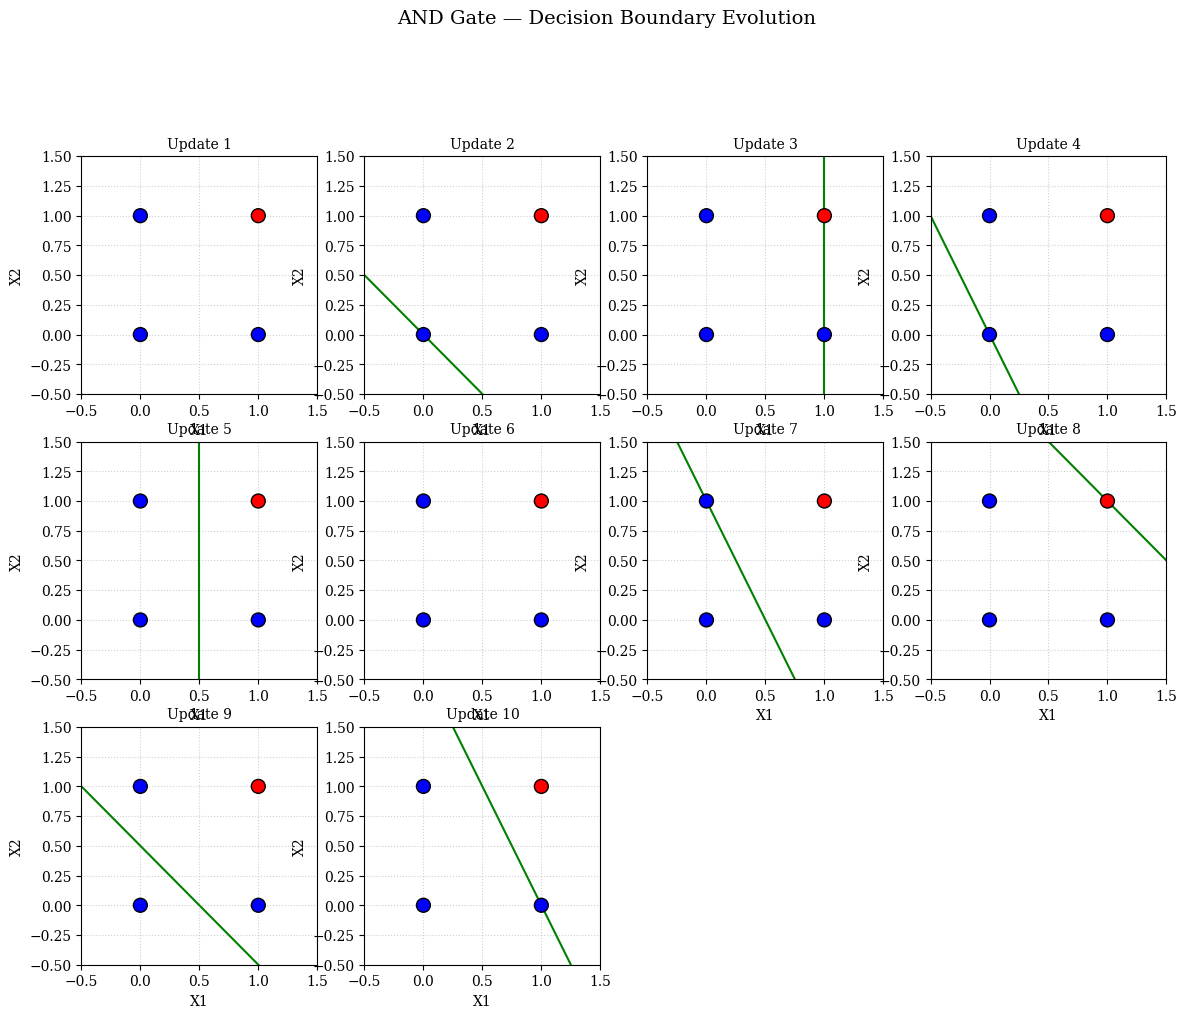


--- End of Epoch 1: Total Misclassifications = 1 ---

--- End of Epoch 2: Total Misclassifications = 2 ---

--- End of Epoch 3: Total Misclassifications = 1 ---

--- End of Epoch 4: Total Misclassifications = 0 ---

OR gate Perceptron converged after epoch 4



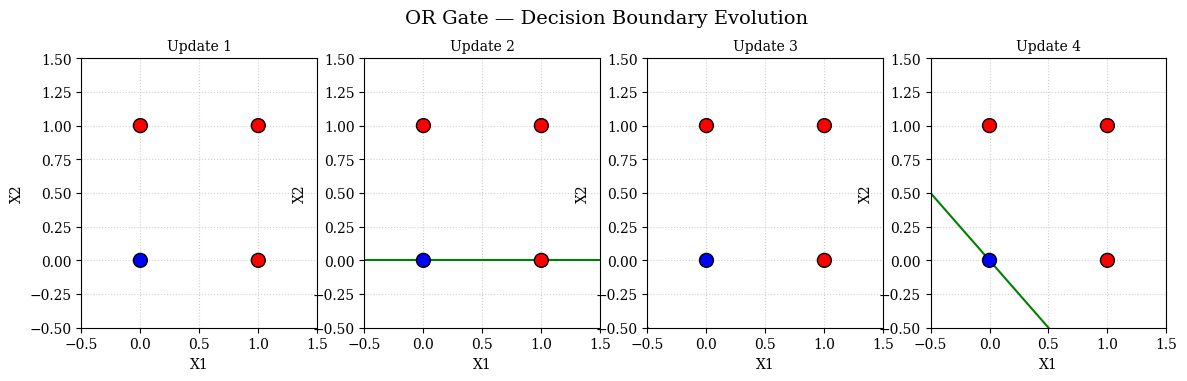


--- End of Epoch 1: Total Misclassifications = 2 ---

--- End of Epoch 2: Total Misclassifications = 1 ---

--- End of Epoch 3: Total Misclassifications = 0 ---

NOT gate Perceptron converged after epoch 3



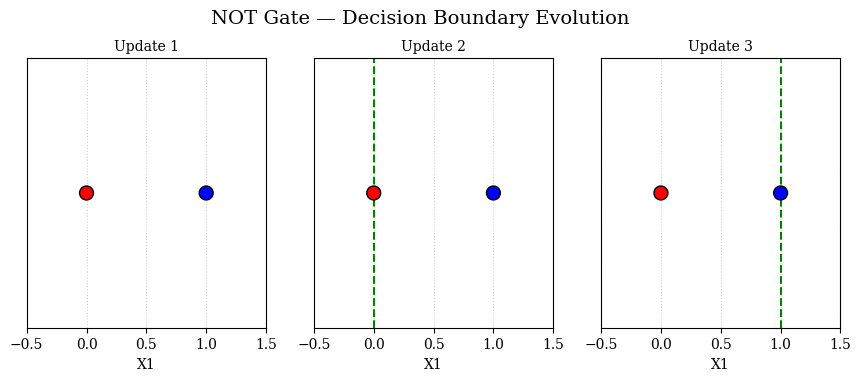

In [16]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
p_and = Perceptron(n=0.1, epochs=10, gate="AND")
p_and.fit(X_and, y_and)
p_and.plot_boundary_history(X_and, y_and)

print()
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])
p_or = Perceptron(n=0.1, epochs=10, gate="OR")
p_or.fit(X_or, y_or)
p_or.plot_boundary_history(X_or, y_or)

print()
X_not = np.array([[0],[1]])
y_not = np.array([1,0])
p_not = Perceptron(n=0.1, epochs=10, gate="NOT")
p_not.fit(X_not, y_not)
p_not.plot_boundary_history(X_not, y_not)